# TensorFlow relies on low-level system libraries (such as protobuf and CUDA). In hosted environments like Kaggle,  version mismatches can cause crashes or excessive logging. Setting environment variables early ensures TensorFlow  initializes safely and quietly.

#  *Mixed precision training* is also enabled, which allows the GPU to use 16-bit floating point arithmetic for most computations. Modern GPUs are significantly faster at 16-bit math, while TensorFlow automatically preserves numerical stability by keeping sensitive values (such as loss and output probabilities) in 32-bit precision.

# This setup improves training speed and memory efficiency without sacrificing model accuracy.

In [1]:
# Environment & GPU stability (MUST be first cell)
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
from tensorflow.keras import mixed_precision

# Enable mixed precision for faster GPU training
mixed_precision.set_global_policy("mixed_float16")

print("GPUs detected:", tf.config.list_physical_devices("GPU"))


2026-01-05 13:42:10.530607: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767620530.735487      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767620530.796263      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767620531.320857      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767620531.320896      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767620531.320899      24 computation_placer.cc:177] computation placer alr

GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report


# Images are resized to a fixed resolution of 224×224 pixels. This size is a standard choice for convolutional networks and is required by pretrained models such as MobileNetV2.

# A fixed random seed is defined to ensure reproducibility across runs.

In [3]:
DATASET_ROOT = "/kaggle/input/plantvillage-dataset"
DATA_VARIANT = "color"

DATASET_PATH = Path(DATASET_ROOT) / DATA_VARIANT
assert DATASET_PATH.exists(), "Dataset path does not exist"

IMG_SIZE = (224, 224)
BATCH_SIZE = 64          # Increased for GPU efficiency
SEED = 42


# Key steps performed automatically:
# - Images are read directly from disk in batches.
# - Pixel values are normalized to the range [0, 1].
# - Data augmentation is applied during training to improve generalization.
# - The dataset is split internally into training (80%) and validation (20%) subsets.

# Data augmentation simulates variations such as rotation, zoom, and horizontal flipping, helping the model become robust to real-world variability without increasing dataset size.


In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

NUM_CLASSES = train_generator.num_classes
CLASS_NAMES = list(train_generator.class_indices.keys())

print(f"Classes: {NUM_CLASSES}")
print("Sample classes:", CLASS_NAMES[:5])


Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Classes: 38
Sample classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


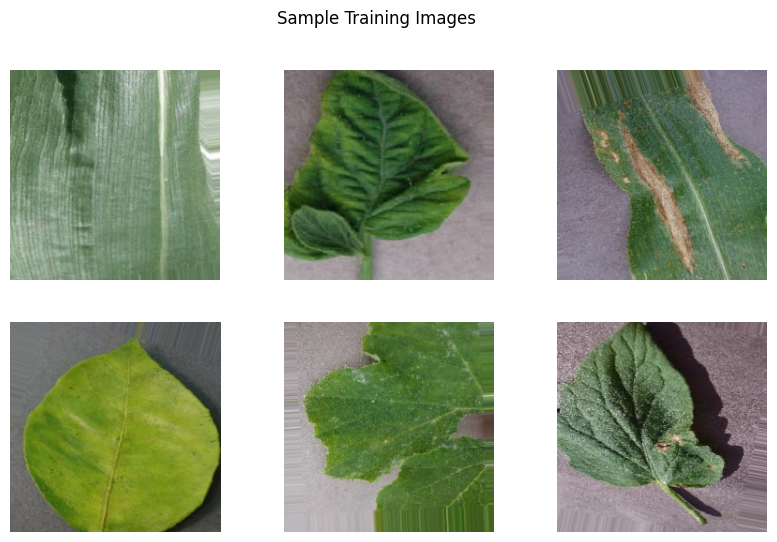

In [5]:
images, labels = next(train_generator)

plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    plt.axis("off")
plt.suptitle("Sample Training Images")
plt.show()


# This model is a simple CNN trained from scratch to understand the fundamentals of convolutional feature learning.

# The network consists of:
# - Convolutional layers that learn local patterns such as edges and textures.
# - Max-pooling layers that reduce spatial resolution and add translation invariance.
# - Fully connected layers that combine learned features for classification.

In [6]:
cnn_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # IMPORTANT: output must be float32 with mixed precision
    layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")
])

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()


I0000 00:00:1767620565.087199      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767620565.091240      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,173,862 (42.62 MB)

 Trainable params: 11,173,862 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

# The CNN is trained using mini-batch gradient descent. During each epoch:
# - Batches of images are passed through the network.
# - The loss is computed using categorical cross-entropy.
# - Gradients are backpropagated to update model weights.

# Training and validation data are evaluated separately to monitor overfitting and generalization.

In [7]:
EPOCHS_CNN = 10

history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_CNN,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_steps=val_generator.samples // BATCH_SIZE,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1767620571.702285      86 service.cc:152] XLA service 0x7e8ed0004ca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767620571.702321      86 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1767620571.702326      86 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1767620572.171375      86 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-05 13:43:05.486531: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng19{k2=0} for conv %cudnn-conv-bw-filter.6 = (f16[128,3,3,64]{3,2,1,0}, u8[0]{0}) custom-call(f16[64,54,54,64]{3,2,1,0} %bitcast.5861, f16[64,52,52,128]{3,2,1,0} %bitcast.5886), window={size=3x3}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", metadata={op_type="Conv2DBackpropFilter" op_name="gradient_tape/sequential_1/conv2d_2_1/convolution/Conv2DBackpropFilter" source_file="

  2/679 ━━━━━━━━━━━━━━━━━━━━ 48s 72ms/step - accuracy: 0.0391 - loss: 4.2919   

I0000 00:00:1767620591.752508      86 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


679/679 ━━━━━━━━━━━━━━━━━━━━ 796s 1s/step - accuracy: 0.2571 - loss: 2.8929 - val_accuracy: 0.5925 - val_loss: 1.3939
Epoch 2/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 639s 941ms/step - accuracy: 0.5225 - loss: 1.6421 - val_accuracy: 0.7234 - val_loss: 0.9614
Epoch 3/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 653s 962ms/step - accuracy: 0.6135 - loss: 1.2837 - val_accuracy: 0.7816 - val_loss: 0.7320
Epoch 4/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 645s 950ms/step - accuracy: 0.6661 - loss: 1.0781 - val_accuracy: 0.8116 - val_loss: 0.6211
Epoch 5/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 616s 907ms/step - accuracy: 0.6982 - loss: 0.9744 - val_accuracy: 0.8394 - val_loss: 0.5157
Epoch 6/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 638s 939ms/step - accuracy: 0.7226 - loss: 0.8966 - val_accuracy: 0.8518 - val_loss: 0.4606
Epoch 7/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 640s 943ms/step - accuracy: 0.7475 - loss: 0.7969 - val_accuracy: 0.8631 - val_loss: 0.4520
Epoch 8/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 654s 964ms/step - accuracy: 0.7627 - loss: 0.7495 

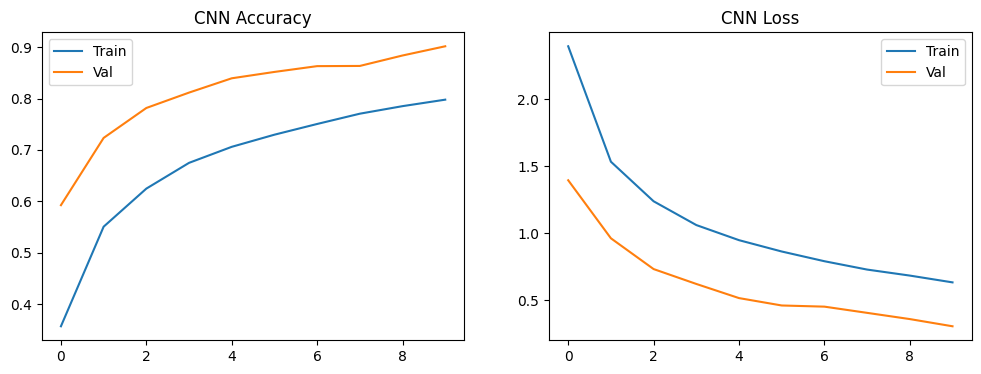

In [8]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_cnn.history["accuracy"], label="Train")
plt.plot(history_cnn.history["val_accuracy"], label="Val")
plt.title("CNN Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn.history["loss"], label="Train")
plt.plot(history_cnn.history["val_loss"], label="Val")
plt.title("CNN Loss")
plt.legend()

plt.show()


# A confusion matrix is generated for the validation set to analyze class-wise performance.

# This visualization reveals:
# - Which disease classes are frequently confused.
# - The effect of class imbalance.
# - Whether errors are systematic or random.

170/170 ━━━━━━━━━━━━━━━━━━━━ 121s 707ms/step


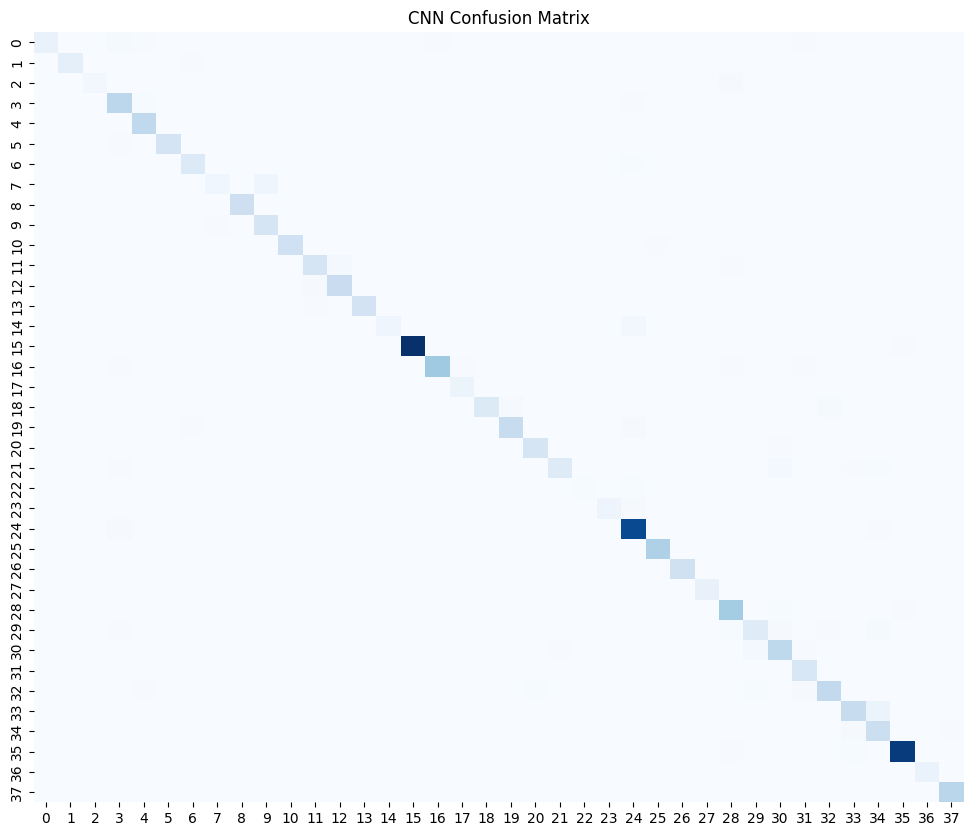

In [9]:
val_generator.reset()
cnn_preds = cnn_model.predict(val_generator)
cnn_y_pred = np.argmax(cnn_preds, axis=1)
cnn_y_true = val_generator.classes

cm_cnn = confusion_matrix(cnn_y_true, cnn_y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm_cnn, cmap="Blues", cbar=False)
plt.title("CNN Confusion Matrix")
plt.show()


# Instead of learning visual features from scratch, a pretrained convolutional network (MobileNetV2) is trained on millions of images from ImageNet.

# The pretrained backbone is frozen to preserve its learned representations. A lightweight classification head is added on top to adapt the model to the PlantVillage dataset.

# This approach drastically reduces training time and improves performance by reusing general-purpose visual features such as edges, textures, and shapes.

In [10]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

tl_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")
])

tl_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

tl_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,854 (9.26 MB)

 Trainable params: 168,870 (659.65 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Callbacks are used to make training more efficient and stable:

# - Early stopping halts training when validation performance stops improving, preventing overfitting.
# - Learning rate reduction lowers the step size when progress plateaus, allowing finer optimization.

In [11]:
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(patience=2, factor=0.3)
]


# Only the newly added classification layers are trained initially, while the pretrained backbone remains frozen.

# This allows the model to quickly adapt to the new task without overwriting valuable pretrained knowledge. Training converges faster and achieves higher accuracy than the CNN trained from scratch.

In [12]:
EPOCHS_TL = 8

history_tl = tl_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_TL,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_steps=val_generator.samples // BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/8
679/679 ━━━━━━━━━━━━━━━━━━━━ 638s 892ms/step - accuracy: 0.6693 - loss: 1.2461 - val_accuracy: 0.9194 - val_loss: 0.2676 - learning_rate: 0.0010
Epoch 2/8
679/679 ━━━━━━━━━━━━━━━━━━━━ 592s 873ms/step - accuracy: 0.8868 - loss: 0.3572 - val_accuracy: 0.9293 - val_loss: 0.2214 - learning_rate: 0.0010
Epoch 3/8
679/679 ━━━━━━━━━━━━━━━━━━━━ 602s 887ms/step - accuracy: 0.9055 - loss: 0.2919 - val_accuracy: 0.9318 - val_loss: 0.2014 - learning_rate: 0.0010
Epoch 4/8
679/679 ━━━━━━━━━━━━━━━━━━━━ 615s 905ms/step - accuracy: 0.9174 - loss: 0.2555 - val_accuracy: 0.9405 - val_loss: 0.1756 - learning_rate: 0.0010
Epoch 5/8
679/679 ━━━━━━━━━━━━━━━━━━━━ 591s 870ms/step - accuracy: 0.9191 - loss: 0.2404 - val_accuracy: 0.9411 - val_loss: 0.1690 - learning_rate: 0.0010
Epoch 6/8
679/679 ━━━━━━━━━━━━━━━━━━━━ 589s 868ms/step - accuracy: 0.9289 - loss: 0.2163 - val_accuracy: 0.9420 - val_loss: 0.1658 - learning_rate: 0.0010
Epoch 7/8
679/679 ━━━━━━━━━━━━━━━━━━━━ 630s 928ms/step - accuracy: 0.9

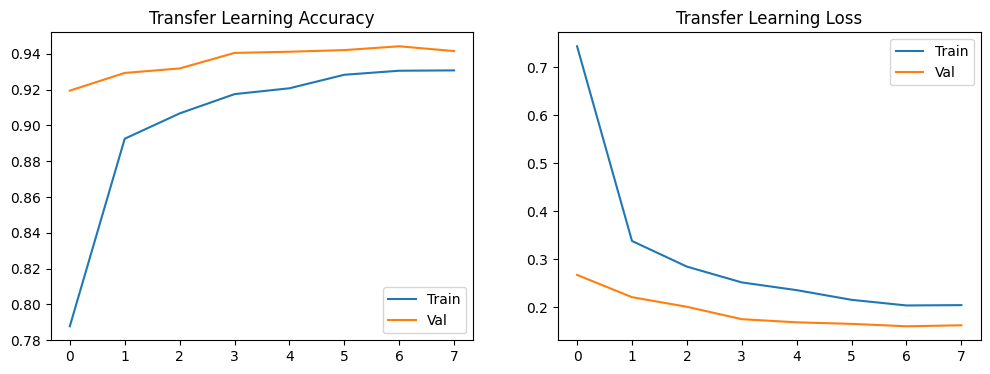

In [13]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_tl.history["accuracy"], label="Train")
plt.plot(history_tl.history["val_accuracy"], label="Val")
plt.title("Transfer Learning Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_tl.history["loss"], label="Train")
plt.plot(history_tl.history["val_loss"], label="Val")
plt.title("Transfer Learning Loss")
plt.legend()

plt.show()


In [14]:
val_generator.reset()
tl_preds = tl_model.predict(val_generator)
tl_y_pred = np.argmax(tl_preds, axis=1)
tl_y_true = val_generator.classes

print(classification_report(
    tl_y_true,
    tl_y_pred,
    target_names=CLASS_NAMES
))


170/170 ━━━━━━━━━━━━━━━━━━━━ 151s 825ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.90      0.95       126
                                 Apple___Black_rot       0.99      0.97      0.98       124
                          Apple___Cedar_apple_rust       0.95      0.98      0.96        55
                                   Apple___healthy       0.97      0.98      0.98       329
                               Blueberry___healthy       0.98      0.98      0.98       300
          Cherry_(including_sour)___Powdery_mildew       0.99      0.99      0.99       210
                 Cherry_(including_sour)___healthy       0.98      0.98      0.98       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.80      0.81      0.81       102
                       Corn_(maize)___Common_rust_       1.00      0.99      0.99       238
               Corn_(maize)___Nort